#**A. Business Background**

##Business Objective and Requirement

###Churn Dataset (Google Drive) :
https://drive.google.com/file/d/1NPEmnXGPNgANwoIjvbdM-q8p93SY78dt/view?usp=sharing

#**B. Data Preparation**

In [ ]:
import pandas as pd                 # Library used for working with data sets and perform data analysis
import numpy as np                  # To perform mathematical operasion and statistics
from datetime import datetime       # Used to perform dates and time manipulation
import seaborn as sns               # To perform data visualization
import matplotlib.pyplot as plt     # To perform data visualization

#**C. Data Cleaning**

##Import Dataset

###Churn Dataset (Google Drive)

In [ ]:
#import dataset csv format from google drive
sheet_url = 'https://drive.google.com/file/d/1NPEmnXGPNgANwoIjvbdM-q8p93SY78dt/view?usp=sharing' #assign link to variable
sheet_url_replace = 'https://drive.google.com/uc?id=' + sheet_url.split('/')[-2] #replace the link

print(sheet_url_replace) #to show the link to csv

df_churn_og = pd.read_csv(sheet_url_replace) #to load/read the csv into pandas dataframe
df_churn_og.head() #show only first 5 rows (to see how the dataset lookslike)

https://drive.google.com/uc?id=1NPEmnXGPNgANwoIjvbdM-q8p93SY78dt


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,3,15619304,Onio,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,4,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


**Data Dictionary :**


* **CustomerId** = contains random values (no effect on customer leaving the bank), as unique code
* **Surname** = the surname of a customer (no impact on their decision to leave the bank)
* **CreditScore** = a customer with a higher credit score is less likely to leave the bank (effect on customer churn)
* **Geography** = a customer’s location (affect their decision to leave the bank)
* **Gender** = gender of a customer (whether gender plays a role in a customer leaving the bank)
* **Age** = age of customer -- this is certainly relevant, since older customers are less likely to leave their bank than younger ones
* **Tenure** = the number of years that the customer has been a client of the bank Normally, older clients are more loyal and less likely to leave a bank
* **Balance** = balance of customer in bank account -- also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances
* **NumOfProducts** = the number of products that a customer has purchased through the bank
* **HasCrCard** = denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank. "0" means customer don't have CC & "1" means to customer have CC
* **IsActiveMember** = active customers are less likely to leave the bank. "0" means no active customer & "1" means to active customer
* **EstimatedSalary** = as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries
* **Exited** = churn indicator. "0" means customer stay on the bank & "1" means to customer leave on the bank




In [ ]:
##make a copy of the original data for data cleaning
df_churn_dc=df_churn_og.copy()

##Check Data type

In [ ]:
#show first 5 data records
df_churn_dc.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,3,15619304,Onio,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,4,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


In [ ]:
#check how much rows and columns
df_churn_dc.shape

(10000, 14)

In [ ]:
#check table info
df_churn_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
#check how much null value exist
df_churn_dc.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Insight
*  CustomerId can be change into string data type (for data type convertion demo purposes). It's mean to act as an identifier, not a numeric value for calculation

Change CustomerId data type from Interger data type into String data type

In [ ]:
#change CustomerId data type into string
df_churn_dc['CustomerId'] = df_churn_dc['CustomerId'].astype(str)

In [ ]:
#check CustomerId data type after replace
df_churn_dc['CustomerId'].dtype

dtype('O')

##Check for Values & Typo

In [ ]:
#check index in dataset
df_churn_dc.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
#check the values of CreditScore
df_churn_dc['CreditScore'].value_counts()

,count
CreditScore,
850,233
678,63
655,54
705,53
667,53
...,...
358,1
412,1
382,1


In [ ]:
#check min & max value of CreditScore
df_churn_dc['CreditScore'].agg(['min', 'max'])

,CreditScore
min,350
max,850


In [ ]:
#check the values of Geography
df_churn_dc['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
#check the values of Gender
df_churn_dc['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [ ]:
#check the values of Age
df_churn_dc['Age'].value_counts()

,count
Age,
37,478
38,477
35,474
36,456
34,447
...,...
84,2
82,1
88,1


In [ ]:
#check min & max value of Age
df_churn_dc['Age'].agg(['min', 'max'])

,Age
min,18
max,92


In [ ]:
#check the values of Tenure
df_churn_dc['Tenure'].value_counts()

,count
Tenure,
2,1048
1,1035
7,1028
8,1025
5,1012
3,1009
4,989
9,984
6,967


In [ ]:
#check the values of NumOfProducts
df_churn_dc['NumOfProducts'].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


In [ ]:
#check the values of HasCrCard
df_churn_dc['HasCrCard'].value_counts()

,count
HasCrCard,
1,7055
0,2945


In [ ]:
#check the values of IsActiveMember
df_churn_dc['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [ ]:
#check the values Exited
df_churn_dc['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


There is no typo were found in this dataset

##Treat Missing and Irrelevant Values

In [ ]:
df_churn_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  object 
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 1.1+ MB


The churn dataset is complete and does not contain any missing values or irrelevant columns, so no preprocessing is needed

##Data Manipulation

In [ ]:
#drop irrelevant column for analysis
df_churn_dc2 = df_churn_dc.drop('RowNumber', axis=1)

In [ ]:
#check column after deleted
df_churn_dc2.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,15647311,Hill,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,15619304,Onio,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


Insight :
*  RowNumber is only used to order rows in the dataset and is not relevant for analysis, therefore it was removed

##Check Duplicate

In [ ]:
#check duplicate data base on primary key "CustomerId"
df_churn_dc2[df_churn_dc2['CustomerId'].duplicated()]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


There is no duplicate rows were found in the churn dataset

In [ ]:
#create a copy card dataset after cleaning for other purpose
df_churn = df_churn_dc2.copy()
df_churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,15647311,Hill,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,15619304,Onio,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


##Detect Outlier

<Axes: xlabel='Balance'>

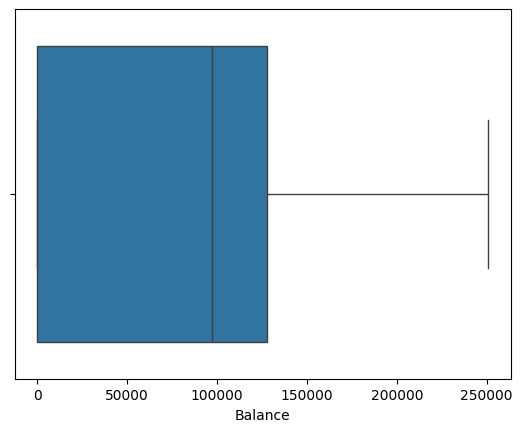

In [ ]:
#check the data distribution of the df_churn_dc data in Balance
sns.boxplot(data = df_churn , x ="Balance")

In [ ]:
#check min & max value of Balance
df_churn['Balance'].agg(['min', 'max'])

,Balance
min,0.000
max,250898.090


<Axes: xlabel='EstimatedSalary'>

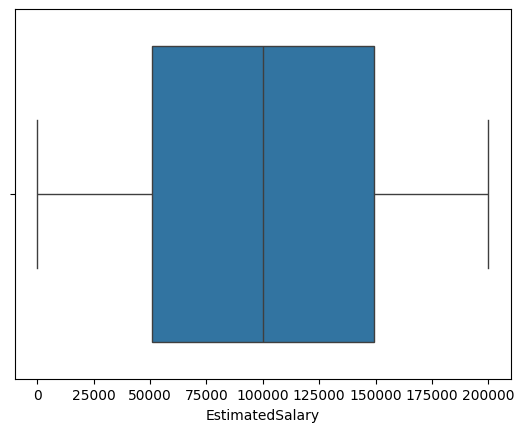

In [ ]:
#check the data distribution of the df_churn_dc data in Balance
sns.boxplot(data = df_churn , x ="EstimatedSalary")

In [ ]:
#check min & max value of EstimatedSalary
df_churn['EstimatedSalary'].agg(['min', 'max'])

,EstimatedSalary
min,11.580
max,199992.480


In [ ]:
#Check the Q1,Q3,IQR,UB & LB
#balance_churn = Balance
print('Outlier Detection "Balance":\n')
balance_Q1 = df_churn['Balance'].quantile(0.25)
print("Q1 =",balance_Q1)

balance_Q3 = df_churn['Balance'].quantile(0.75)
print("Q3 =",balance_Q3)

balance_IQR = balance_Q3 - balance_Q1
print("IQR =",balance_IQR)

balance_LB = balance_Q1-1.5*balance_IQR
print("LB =",balance_LB)

balance_UB = balance_Q3+1.5*balance_IQR
print("UB =",balance_UB)


#Check the Q1,Q3,IQR,UB & LB
#est_salary = EstimatedSalary
print('Outlier Detection "EstimatedSalary":\n')
est_salary_Q1 = df_churn['EstimatedSalary'].quantile(0.25)
print("Q1 =",est_salary_Q1)

est_salary_Q3 = df_churn['EstimatedSalary'].quantile(0.75)
print("Q3 =",est_salary_Q3)

est_salary_IQR = est_salary_Q3 - est_salary_Q1
print("IQR =",est_salary_IQR)

est_salary_LB = est_salary_Q1-1.5*est_salary_IQR
print("LB =",est_salary_LB)

est_salary_UB = est_salary_Q3+1.5*est_salary_IQR
print("UB =",est_salary_UB)


Outlier Detection "Balance":

Q1 = 0.0
Q3 = 127644.24
IQR = 127644.24
LB = -191466.36000000002
UB = 319110.60000000003
Outlier Detection "EstimatedSalary":

Q1 = 51002.11
Q3 = 149388.2475
IQR = 98386.1375
LB = -96577.09624999999
UB = 296967.45375


In [ ]:
#check how much outlier if remove all the outlier of Balance and EstimatedSalary
df_clean_balance = df_churn[~((df_churn_dc["Balance"] < balance_LB) | (df_churn["Balance"] > balance_UB))]
df_clean_est_salary = df_clean_balance[~((df_clean_balance["EstimatedSalary"] < est_salary_LB) | (df_clean_balance["EstimatedSalary"] > est_salary_UB))]

df_clean_est_salary.shape

(10000, 13)

Insight

1. Balance :
*  Because there are no Balance values outside this range, the Balance **variable does not have any extreme outliers**.
*   Furthermore, the boxplot shows that the data distribution tends to be right-skewed, with a small percentage of customers having significantly higher balances than the majority. The median balance is around 100,000, with a fairly wide spread in the data, indicating a significant variation in balances among customers.
*   Q1 value of 0 also indicates that a significant number of customers have very low or even zero balances.
*   Customers with zero balance do not necessarily churn because many customers still maintain active banking relationships through other banking services, payroll accounts, or transactional usage despite having no deposit balance.

2. EstimatedSalary :
*  No EstimatedSalary values were found outside the lower or upper limits, indicating that this **variable has no outliers**.
*  Furthermore, the boxplot shows a relatively symmetrical data distribution with a median of approximately 100,000. The data distribution is quite wide, indicating that the variation in income estimates between customers is quite high, but remains within a reasonable range.


#**D. EDA**

In [ ]:
#preparing a copy of df_clean for EDA
df_eda = df_churn.copy()
df_eda.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,15647311,Hill,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,15619304,Onio,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


##Descriptive Statistics :

###Descriptive information about numeric variable

In [ ]:
df_eda.select_dtypes(include=['number']).columns.to_list()

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [ ]:
#descriptive analysis after treating the outlier
pd.set_option('display.float_format', lambda x: '%.3f' % x) #Used to display float numbers in pandas with 3 decimal places.

numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
           'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

desc_eda = df_eda[numeric].describe()
desc_eda.loc['kurtosis'] = df_eda[numeric].kurt() #show kurtosis index for statistic
desc_eda.loc['skewness'] = df_eda[numeric].skew() #show Skewness index for statistic
desc_eda.loc['variance'] = df_eda[numeric].var() #show variance index for statistic
desc_eda.round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,650.530,38.920,5.010,76485.890,1.530,0.710,0.520,100090.240,0.200
std,96.650,10.490,2.890,62397.410,0.580,0.460,0.500,57510.490,0.400
min,350.000,18.000,0.000,0.000,1.000,0.000,0.000,11.580,0.000
25%,584.000,32.000,3.000,0.000,1.000,0.000,0.000,51002.110,0.000
50%,652.000,37.000,5.000,97198.540,1.000,1.000,1.000,100193.920,0.000
75%,718.000,44.000,7.000,127644.240,2.000,1.000,1.000,149388.250,0.000
max,850.000,92.000,10.000,250898.090,4.000,1.000,1.000,199992.480,1.000
kurtosis,-0.430,1.400,-1.170,-1.490,0.580,-1.190,-2.000,-1.180,0.170
skewness,-0.070,1.010,0.010,-0.140,0.750,-0.900,-0.060,0.000,1.470


Insight :
* The dataset contains 10,000 customer records
* The average credit score is 650, ranging from 350 to 850
* The average customer age is 39 years old, with ages ranging from 18 to 92 years
* Customers have an average tenure of 5 years
* The average account balance is USD 76,485.89, while some customers have zero balance accounts
* Most customers own 1 to 2 banking products, with the maximum reaching 4 products
* Approximately 71% of customers have a credit card
* Around 52% of customers are active members
* The average estimated salary is USD 100,090.24
* The churn rate (Exited = 1) is approximately 20% of total customers

###Descriptive information about string variable

In [ ]:
df_eda.select_dtypes(include=['object']).columns.to_list()

['CustomerId', 'Surname', 'Geography', 'Gender']

In [ ]:
#descriptive analysis after treating the outlier
objects = ['CustomerId', 'Surname', 'Geography', 'Gender']
df_eda[objects].describe()

,CustomerId,Surname,Geography,Gender
count,10000,10000,10000,10000
unique,10000,2932,3,2
top,15656710,Smith,France,Male
freq,1,32,5014,5457


Insight :
* The dataset contains 10,000 customers
* Most customers are male (5.457 records)
* Most customers are located in France (5,014 customers)

###Churn Rate, Retention Rate, Active Customer Rate, Average Balance, Average Product per Customer

In [ ]:
#calculate KPI Feasibility

#1. Churn Rate
#churn rate = exited customer / total customer * 100%
#calculate total customer and total customer
total_customer = len(df_eda)
churn_customer = df_eda['Exited'].sum()
#calculate churn rate
churn_rate = (churn_customer / total_customer) * 100

#2. Retention Rate
#retention rate = 100% - churn rate or retained customer / total customer * 100%
#calculate retained customer
retained_customer = (df_eda['Exited'] == 0).sum()
#calculate retention rate
retention_rate = (retained_customer / total_customer) * 100

#3. Active Customer Rate
#active customer rate = active custimer / total customer * 100%
#calculate active customer
active_customer = df_eda['IsActiveMember'].sum()
#calculate active customer rate
active_customer_rate = (active_customer / total_customer) * 100

#4. Average Balance
avg_balance = df_eda['Balance'].mean()

#5. Average Product per Customer
avg_product = df_eda['NumOfProducts'].mean()

print(f"Total Customers              : {total_customer:,}")
print(f"Churn Rate                   : {churn_rate:.2f}%")
print(f"Retention Rate               : {retention_rate:.2f}%")
print(f"Active Customer Rate         : {active_customer_rate:.2f}%")
print(f"Average Balance              : {avg_balance:,.2f}")
print(f"Average Product per Customer : {avg_product:.2f}")

Total Customers              : 10,000
Churn Rate                   : 20.37%
Retention Rate               : 79.63%
Active Customer Rate         : 51.51%
Average Balance              : 76,485.89
Average Product per Customer : 1.53


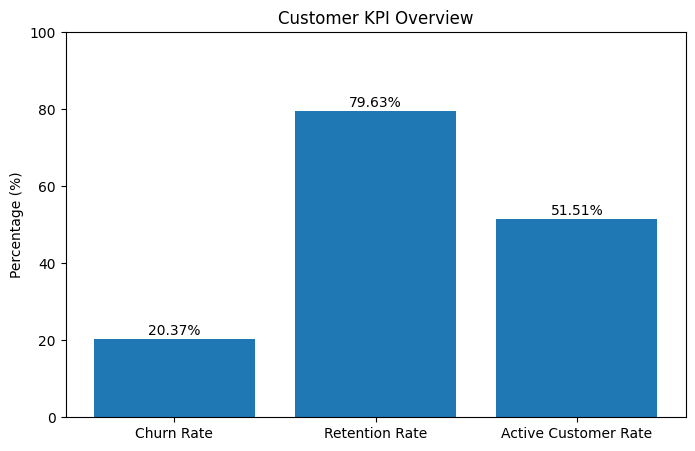

In [ ]:
#create the bar chart of Churn Rate, Retention Rate & Active Customer Rate
#data KPI
kpi_names = ['Churn Rate', 'Retention Rate', 'Active Customer Rate']
kpi_values = [churn_rate, retention_rate, active_customer_rate]

#draw chart
plt.figure(figsize=(8,5))

bars = plt.bar(kpi_names, kpi_values)

#create label
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        f'{yval:.2f}%',
        ha='center')

#create title
plt.title('Customer KPI Overview')
plt.ylabel('Percentage (%)')

plt.ylim(0,100)

plt.show()

<Figure size 800x500 with 0 Axes>

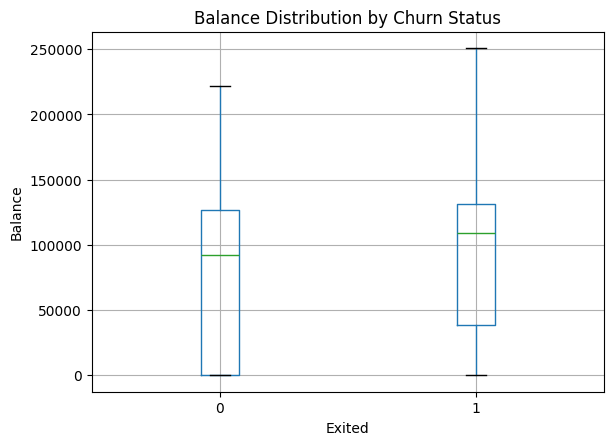

In [ ]:
plt.figure(figsize=(8,5))

df_eda.boxplot(column='Balance', by='Exited')

plt.title('Balance Distribution by Churn Status')
plt.suptitle('')
plt.xlabel('Exited')
plt.ylabel('Balance')

plt.show()

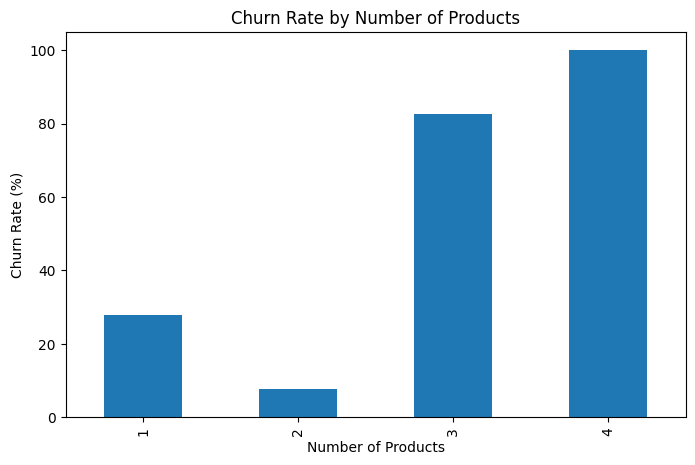

In [ ]:
#calculate product churn
product_churn = df_eda.groupby('NumOfProducts')['Exited'].mean() * 100

plt.figure(figsize=(8,5))

product_churn.plot(kind='bar')

plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')

plt.show()

Insight :
* Customer churn rate reached 20.37%, indicating that approximately 1 in 5 customers are at risk of leaving the bank.
* The distribution of churned customers' balances also tends to be higher overall. Many churned customers have large balances (>100,000).
* Customers who own four products exhibit a 100% churn rate, while customers with three products show an 85% churn rate. In contrast, customers with two products demonstrate the strongest retention behavior. This indicates that higher product ownership alone is insufficient to guarantee customer loyalty and suggests that product relevance and customer engagement play a more critical role in retention.

###Active vs Inactive Customer Rate

In [ ]:
#calculate active customer
active_customer = (df_eda['IsActiveMember'] == 1).sum()
#calculate inactive customer
inactive_customer = (df_eda['IsActiveMember'] == 0).sum()
#calculate active customer rate
active_rate = (active_customer / total_customer) * 100
#calculate inactive customer rate
inactive_rate = (inactive_customer / total_customer) * 100

print(f"Total Customer      : {total_customer:,}")
print(f"Active Customer     : {active_customer:,}")
print(f"Inactive Customer   : {inactive_customer:,}")
print(f"Active Rate         : {active_rate:.2f}%")
print(f"Inactive Rate       : {inactive_rate:.2f}%")

Total Customer      : 10,000
Active Customer     : 5,151
Inactive Customer   : 4,849
Active Rate         : 51.51%
Inactive Rate       : 48.49%


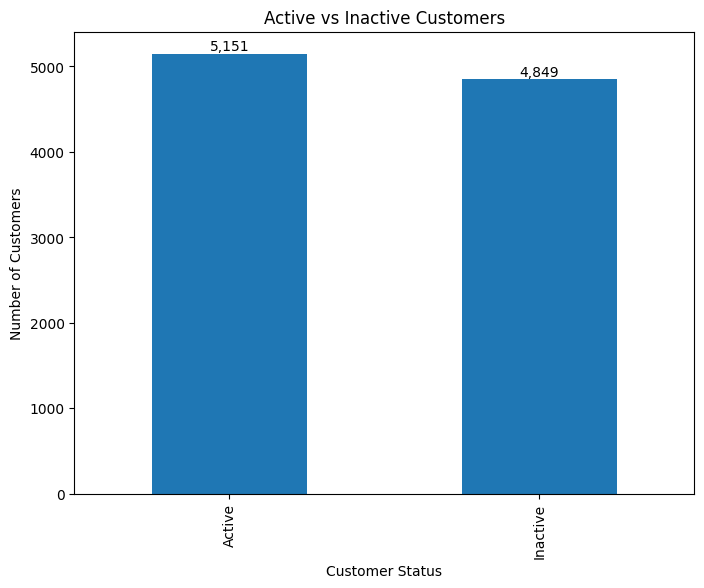

In [ ]:
#draw the bar chart
activity = df_eda['IsActiveMember'].value_counts()
activity.index = ['Active', 'Inactive']

plt.figure(figsize=(8,6))
ax = activity.plot(kind='bar')

#add label
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        f'{height:,}',
        ha='center',
        va='bottom')

plt.title('Active vs Inactive Customers')
plt.ylabel('Number of Customers')
plt.xlabel('Customer Status')

plt.show()

Insight :
* Active customer rate is 51.51%, means only around half of customers are actively engaged with the bank, indicating potential engagement and retention challenges.

###Churn Rate by Activity Status

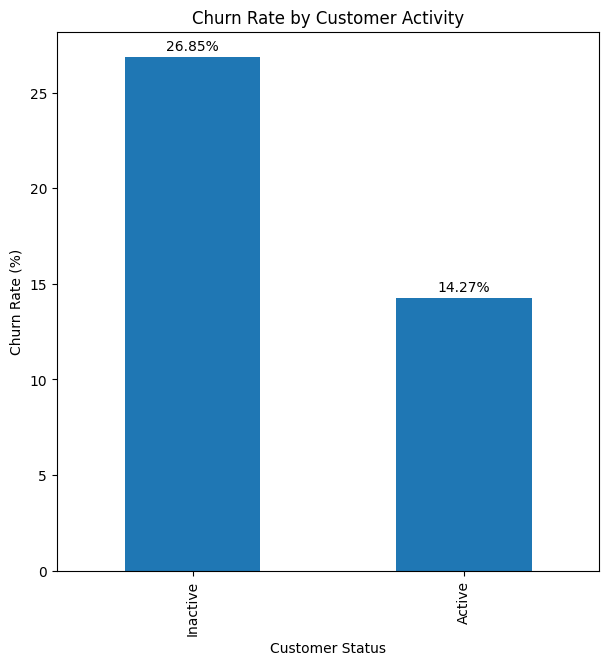

In [ ]:
#calculate churn rate by activity status
activity_churn = df_eda.groupby('IsActiveMember')['Exited'].mean() * 100

activity_churn.index = ['Inactive', 'Active']

plt.figure(figsize=(7,7))

ax = activity_churn.plot(kind='bar')

# Tambahkan label di atas bar
for i, value in enumerate(activity_churn):
    ax.text(i, value + 0.2, f'{value:.2f}%', ha='center', va='bottom')

plt.title('Churn Rate by Customer Activity')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Customer Status')

plt.show()

Insight :
* Inactive customers exhibit a significantly higher churn rate of 26.85%, nearly double that of active customers at 14.27%. This highlights customer inactivity as a major churn indicator. However, the active segment still shows a meaningful churn level, indicating that customer activity alone is insufficient to guarantee long-term loyalty and that deeper engagement strategies remain necessary.
* Therefore, retention strategies should focus not only on maintaining customer activity, but also on strengthening deeper engagement and customer relationships.

###Average Balance Churn vs Non-Churn Customer

In [ ]:
#calculate average churn customer
avg_balance_churn = df_eda.groupby('Exited')['Balance'].mean()
#calculate average non-churn customer
avg_balance_churn.index = ['Non-Churn', 'Churn']

print(avg_balance_churn)

Non-Churn   72745.297
Churn       91108.539
Name: Balance, dtype: float64


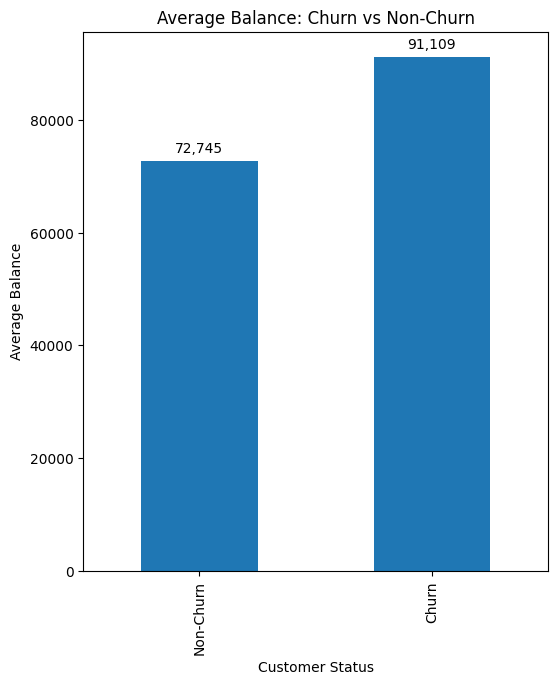

In [ ]:
#draw the bar chart of average balance churn vs non-churn
avg_balance_churn = df_eda.groupby('Exited')['Balance'].mean()

avg_balance_churn.index = ['Non-Churn', 'Churn']

plt.figure(figsize=(6,7))

ax = avg_balance_churn.plot(kind='bar')

#create label
for i, value in enumerate(avg_balance_churn): ax.text(i, value + 1000,
    f'{value:,.0f}', ha='center', va='bottom')

plt.title('Average Balance: Churn vs Non-Churn')
plt.ylabel('Average Balance')
plt.xlabel('Customer Status')

plt.show()

Insight :
* Churned customers maintain a significantly higher average balance (USD 91,109) compared to non-churn customers (USD 72,745), indicating that the bank is losing disproportionately valuable customers. This suggests that financial value alone does not guarantee customer loyalty, and high-balance customers may require more personalized engagement and retention strategies.

###Churn Rate among High Balance Customer

In [ ]:
#define high balance customer
high_balance = df_eda[df_eda['Balance'] > 100000]

In [ ]:
#calculate Churn Rate
high_balance_churn_rate = high_balance['Exited'].mean() * 100

print(f"Churn Rate among High Balance Customers: {high_balance_churn_rate:.2f}%")

Churn Rate among High Balance Customers: 25.23%


In [ ]:
#calculate total high balance customer
total_high_balance = len(high_balance)

churn_high_balance = high_balance['Exited'].sum()

print(f"Total High Balance Customers : {total_high_balance}")
print(f"Churned Customers            : {churn_high_balance}")

Total High Balance Customers : 4799
Churned Customers            : 1211


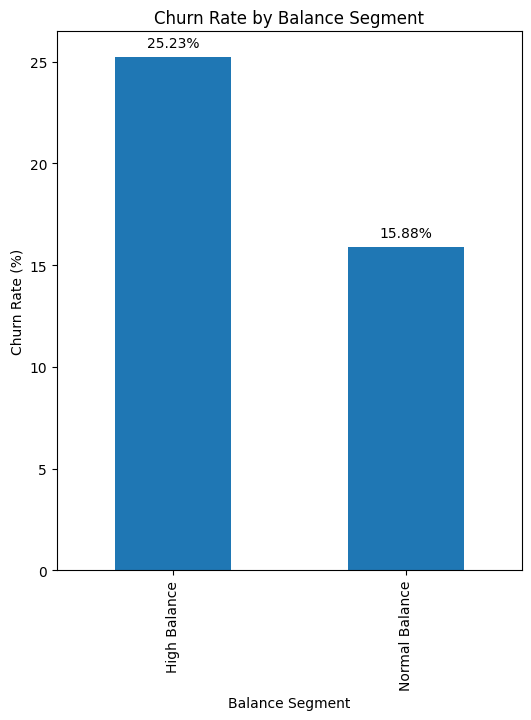

In [ ]:
#draw the bar chart
balance_segment = df_eda.copy()

balance_segment['BalanceSegment'] = balance_segment['Balance'].apply(
    lambda x: 'High Balance' if x > 100000 else 'Normal Balance')

segment_churn = balance_segment.groupby('BalanceSegment')['Exited'].mean() * 100

plt.figure(figsize=(6,7))

ax = segment_churn.plot(kind='bar')

#create label
for i, value in enumerate(segment_churn): ax.text(i, value + 0.5,
    f'{value:.2f}%', ha='center')

plt.title('Churn Rate by Balance Segment')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Balance Segment')

plt.show()

Insight :
* High-balance customers exhibit a churn rate of 25.23%, with 1,211 out of 4,799 customers leaving the bank. This indicates that a significant portion of valuable customers are still churning despite their substantial financial contribution. The finding suggests that financial value alone is insufficient to ensure loyalty, highlighting the need for personalized retention strategies and stronger relationship management for high value customer segments.

###Average Tenure Churn vs Non-Churn

In [ ]:
#calculate average tenure
avg_tenure = df_eda['Tenure'].mean()

print(f"Average Tenure: {avg_tenure:.2f} years")

Average Tenure: 5.01 years


In [ ]:
#calculate average Tenure Churn vs Non-Churn
avg_tenure_churn = df_eda.groupby('Exited')['Tenure'].mean()

avg_tenure_churn.index = ['Non-Churn', 'Churn']

print(avg_tenure_churn)

Non-Churn   5.033
Churn       4.933
Name: Tenure, dtype: float64


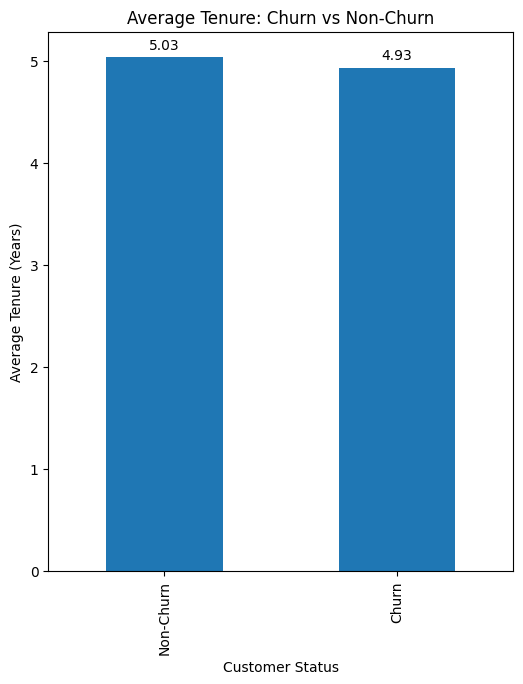

In [ ]:
#draw the bar chart
avg_tenure_churn = df_eda.groupby('Exited')['Tenure'].mean()

avg_tenure_churn.index = ['Non-Churn', 'Churn']

plt.figure(figsize=(6,7))

ax = avg_tenure_churn.plot(kind='bar')

#create label
for i, value in enumerate(avg_tenure_churn): ax.text(i, value + 0.05,
    f'{value:.2f}', ha='center', va='bottom')

plt.title('Average Tenure: Churn vs Non-Churn')
plt.ylabel('Average Tenure (Years)')
plt.xlabel('Customer Status')

plt.show()

Insight :
* The average customer tenure is approximately 5 years, with churned customers showing a slightly shorter tenure (4.93 years) compared to retained customers (5.03 years). This suggests that tenure alone has a relatively weak relationship with churn behavior, indicating that customer engagement and behavioral factors may play a more significant role in retention.

###Churn Rate by Tenure Segment

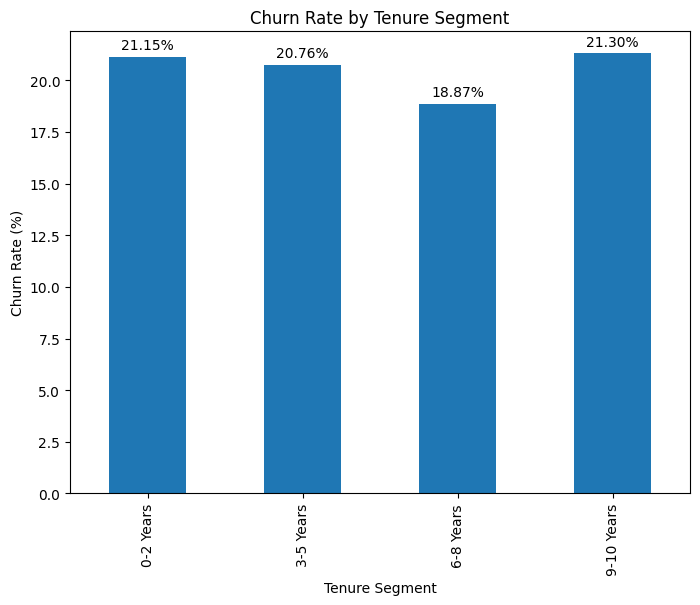

In [ ]:
#create tenure segment
df_eda['TenureSegment'] = pd.cut(
    df_eda['Tenure'],
    bins=[0, 2, 5, 8, 10],
    labels=[
        '0-2 Years',
        '3-5 Years',
        '6-8 Years',
        '9-10 Years'
    ], include_lowest=True)

#calculate churn rate
tenure_churn = df_eda.groupby('TenureSegment', observed=False)['Exited'].mean() * 100

#draw the bar chart
plt.figure(figsize=(8,6))

ax = tenure_churn.plot(kind='bar')

#add label
for i, value in enumerate(tenure_churn): ax.text(i, value + 0.2, f'{value:.2f}%',
        ha='center', va='bottom')

plt.title('Churn Rate by Tenure Segment')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Segment')

plt.show()

Insight :
* Churn rates are relatively stable at around 18-21% across all tenure segments, indicating that customer loyalty does not increase significantly with the length of the relationship with the company.

###Churn Rate by Geography

In [ ]:
#create churn by geography
churn_by_geo = (df_eda.groupby('Geography')['Exited'].mean().reset_index())

churn_by_geo['ChurnRate (%)'] = churn_by_geo['Exited'] * 100
churn_by_geo = churn_by_geo.sort_values('ChurnRate (%)', ascending=False)

churn_by_geo

,Geography,Exited,ChurnRate (%)
1,Germany,0.324,32.443
2,Spain,0.167,16.673
0,France,0.162,16.155


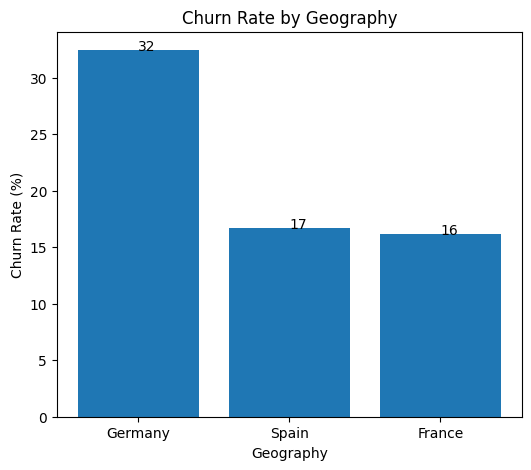

In [ ]:
#draw the bar chart
plt.figure(figsize=(6,5))

bars = plt.bar(churn_by_geo['Geography'], churn_by_geo['ChurnRate (%)'])

plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')

#add label
for bar in bars:
    height = bar.get_height(); plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}')
plt.show()

Insight :
* Customer churn in Germany is around 32%, while in France and Spain it's only around 16%, means customers in Germany have a much higher risk of churn than in other countries.

In [ ]:
from scipy.stats import chi2_contingency

cross_tab = pd.crosstab(df_eda['Geography'], df_eda['Exited'])
chi2_contingency(cross_tab)

Chi2ContingencyResult(statistic=np.float64(301.25533682434536), pvalue=np.float64(3.8303176053541544e-66), dof=2, expected_freq=array([[3992.6482, 1021.3518],
       [1997.9167,  511.0833],
       [1972.4351,  504.5649]]))

###Churn Rate by Credit Card Ownership

In [ ]:
df_eda['CreditCardStatus'] = df_eda['HasCrCard'].map({
    0: 'No Credit Card',
    1: 'Has Credit Card'
})

df_eda['CreditCardStatus'].value_counts(normalize=True) * 100

,proportion
CreditCardStatus,
Has Credit Card,70.550
No Credit Card,29.450


In [ ]:
df_eda.groupby('HasCrCard')['Exited'].mean() * 100

,Exited
HasCrCard,
0,20.815
1,20.184


Insight :
* Credit card ownership does not significantly influence churn behavior, as churn rates between customers with and without credit cards are nearly identical (~20%). This suggests that credit card presence is not a meaningful retention factor.

###Churn Rate by Credit Score Segment

In [ ]:
#calculate average credit score in whole customer
avg_credit_score = df_eda['CreditScore'].mean()
print(f"Average Credit Score: {avg_credit_score:.2f}")

Average Credit Score: 650.53


In [ ]:
#calculate average credit score customer by churn
df_eda.groupby('Exited')['CreditScore'].mean()

,CreditScore
Exited,
0,651.853
1,645.351


In [ ]:
#create credit score segment
df_eda['CreditScoreSegment'] = pd.qcut(df_eda['CreditScore'].rank(method='first'),
    3, labels=['Low', 'Medium', 'High'])

In [ ]:
#calculate churn rate by credit score segment
churn_by_cs = (df_eda.groupby('CreditScoreSegment', observed=False)['Exited']
    .mean().reset_index())

churn_by_cs.columns = ['CreditScoreSegment', 'ChurnRate (%)']
churn_by_cs

,CreditScoreSegment,ChurnRate (%)
0,Low,0.216
1,Medium,0.198
2,High,0.198


Insight :
* Credit scores show only a weak correlation with churn rates, with low-scoring customers exhibiting a slightly higher churn rate (21.6% vs 19.8%), indicating that credit score is not a key driver of churn behavior.

###Churn Rate by Age Group

In [ ]:
#create bin of age
bins = [0, 30, 45, 60, 100]
labels = ['Young', 'Adult', 'Middle Age', 'Senior']

df_eda['AgeGroup'] = pd.cut(df_eda['Age'], bins=bins, labels=labels)

In [ ]:
#calculate churn rate per age group
churn_by_age = df_eda.groupby('AgeGroup', observed=False)['Exited'].mean() * 100
print(churn_by_age)

AgeGroup
Young         7.520
Adult        15.741
Middle Age   51.123
Senior       24.784
Name: Exited, dtype: float64


In [ ]:
#compare with total customer
summary = df_eda.groupby('AgeGroup', observed=False).agg(
    Total_Customer=('CustomerId', 'count'), Churn_Rate=('Exited', 'mean'))

summary['Churn_Rate'] = summary['Churn_Rate'] * 100
print(summary)

            Total_Customer  Churn_Rate
AgeGroup                              
Young                 1968       7.520
Adult                 5921      15.741
Middle Age            1647      51.123
Senior                 464      24.784


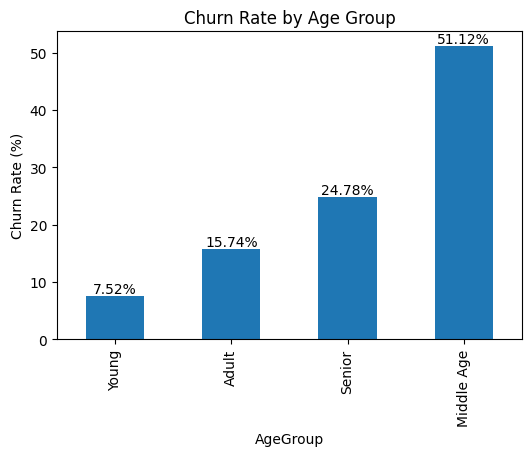

In [ ]:
#draw the bar chart
ax = churn_by_age.sort_values().plot(kind='bar', figsize=(6,4))

plt.title('Churn Rate by Age Group')
plt.ylabel('Churn Rate (%)')

#add label
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom')

plt.show()

Insight :
* Customers in the middle-age group (46-60 years old) have the highest churn rate at 51.12%, indicating a potential serious issue with retention in the mature working age segment.

###Churn Rate by Gender

In [ ]:
#calculate churn rate by gender
churn_by_gender = df_eda.groupby('Gender').agg(
    Total_Customer=('CustomerId', 'count'),
    Churn_Rate=('Exited', 'mean'))

churn_by_gender['Churn_Rate'] = churn_by_gender['Churn_Rate'] * 100
print(churn_by_gender)

        Total_Customer  Churn_Rate
Gender                            
Female            4543      25.072
Male              5457      16.456


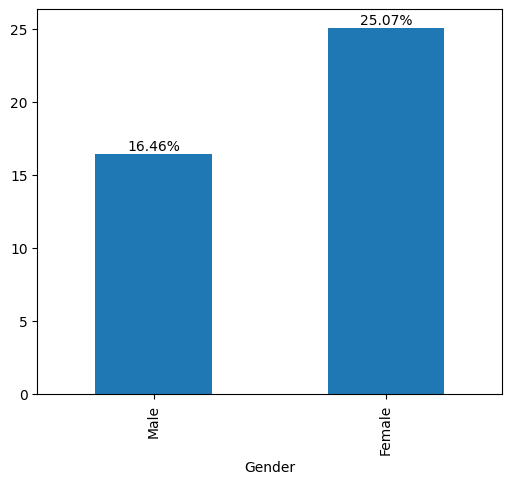

In [ ]:
#draw the bar chart
ax = churn_by_gender.sort_values(by='Churn_Rate').plot(
    y='Churn_Rate', kind='bar', figsize=(6,5),
    legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

Insight :
* Churn rate based on gender shows that female customers have a higher churn rate (25.07%) compared to males (16.46%). This indicates a difference in behavior or needs that can become a focus for further analysis for a more targeted retention strategy.

In [ ]:
from google.colab import files

#save dataframe become csv
df_churn.to_csv('churn_data.csv', index=False)

#download to device
files.download('churn_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  object 
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1015.8+ KB
